## Exercise: Clustering and geospatial analysis

#### In this notebook, we'll use geopandas to plot geospatial data and create multidimensional plots by adjusting size and colour.

### **Learning Objectives**
#### By the end of this notebook, you should be able to:
#### - Create multidimensional plots by adjusting size and color.
#### - Use geopandas to plot geospatial data

### **Exercises**

### **Exercise 1: Basic geospatial plotting**
#### Plot the world map using `geopandas`, colouring the countries based on their GDP per capita

#### **Hint**: Use the 'plot' method with the 'column' parameter set to 'gdp_md_est'

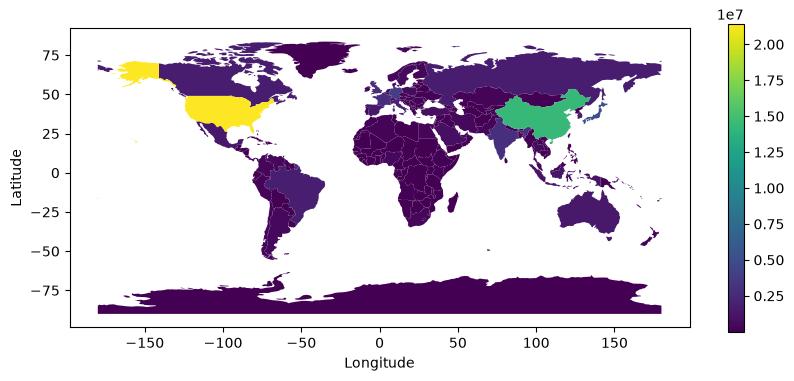

In [51]:
import geopandas as gpd
import matplotlib.pyplot as plt

# load example geospatial dataset
world = gpd.read_file('/vsicurl/https://github.com/Explore-AI/Public-Data/raw/master/naturalearth_lowres/ne_110m_admin_0_countries.shp')

# world['GDP_per_capita'] = (world['GDP_MD'] * 1000000) / world['POP_EST']

ax = world.plot(
    # column='GDP_per_capita',
    column='GDP_MD',
    cmap='viridis',
    legend=True,
    figsize=(10,8),
    legend_kwds={'shrink': 0.5}
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

### Exercise 2: Adjusting size and color in geospatial plots

#### Create a plot where the size of each country is determined by its population and the color is determined by its GDP per capita.
#### **Hint:**
#### 1. Use the geometrics of countries from the `geopandas` dataframe for the map
#### 2. Overlay a scatter plot to adjust the size of the countries based on their population

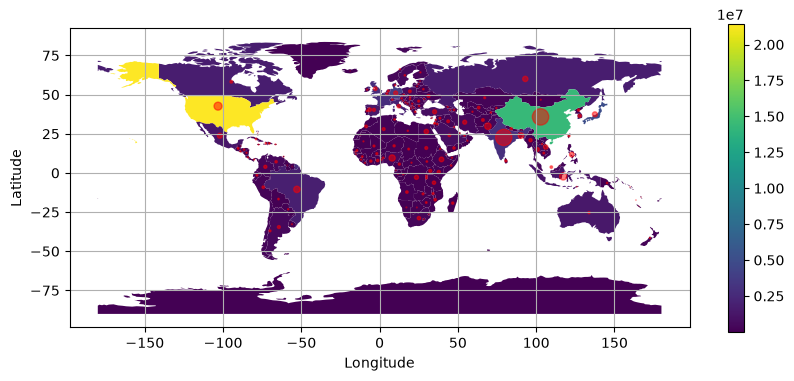

In [55]:
import geopandas as gpd
import matplotlib.pyplot as plt

# load example geospatial dataset
world = gpd.read_file('/vsicurl/https://github.com/Explore-AI/Public-Data/raw/master/naturalearth_lowres/ne_110m_admin_0_countries.shp')

# world['GDP_per_capita'] = (world['GDP_MD'] * 1000000) / world['POP_EST']
ax = world.plot(
    # column='GDP_per_capita',
    column='GDP_MD',
    cmap='viridis',
    # markersize='POP_EST',
    legend=True,
    figsize=(10,8),
    legend_kwds={'shrink': 0.5}
)

# reprojecting to a projected CRS before recalculating centroids
world_points = world.to_crs("ESRI:54009").copy()
world_points['geometry'] = world_points.geometry.centroid
world_points = world_points.to_crs(world.crs)
# world_points = world.copy()
# world_points['geometry'] = world_points.geometry.centroid

world_points.plot(
    ax=ax,
    markersize=world_points['POP_EST'] / 10000000,
    color='red',
    alpha=0.5
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.grid(True)
plt.show()

### Exercise 3: Geospatial clustering analysis

#### Use K-means clustering to group countries based on their GDP and population, then plot the clusters on the map with different colours.
#### **Hint**: Use `KMeans` from `sklearn.cluster` and the `plot` method from geopandas

In [37]:
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

# load example geospatial dataset
world = gpd.read_file('/vsicurl/https://github.com/Explore-AI/Public-Data/raw/master/naturalearth_lowres/ne_110m_admin_0_countries.shp')

# Prepare data for clustering
data = world[['GDP_MD', 'POP_EST']].dropna()
data_scaled = scaler.fit_transform(data)

inertias = []

for k in range(2, 12):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(data_scaled)
    inertias.append(kmeans.inertia_)

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\sit

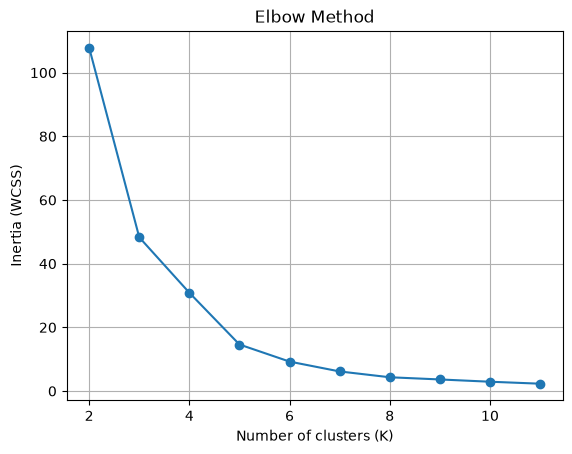

In [38]:
k_values = range(2, 12)

plt.plot(
    k_values,
    inertias,
    marker='o'
)

plt.xlabel('Number of clusters (K)')
plt.ylabel('Inertia (WCSS)')
plt.title('Elbow Method')

plt.grid(True)
plt.show()

In [39]:
kmeans_final = KMeans(
    n_clusters=8,
    random_state=42,
    n_init=10
)

labels = kmeans_final.fit_predict(data_scaled)
world['cluster'] = labels

D:\Users\steph\anaconda3\envs\ALX_Machine_learning\Lib\site-packages\sklearn\cluster\_kmeans.py:1424: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


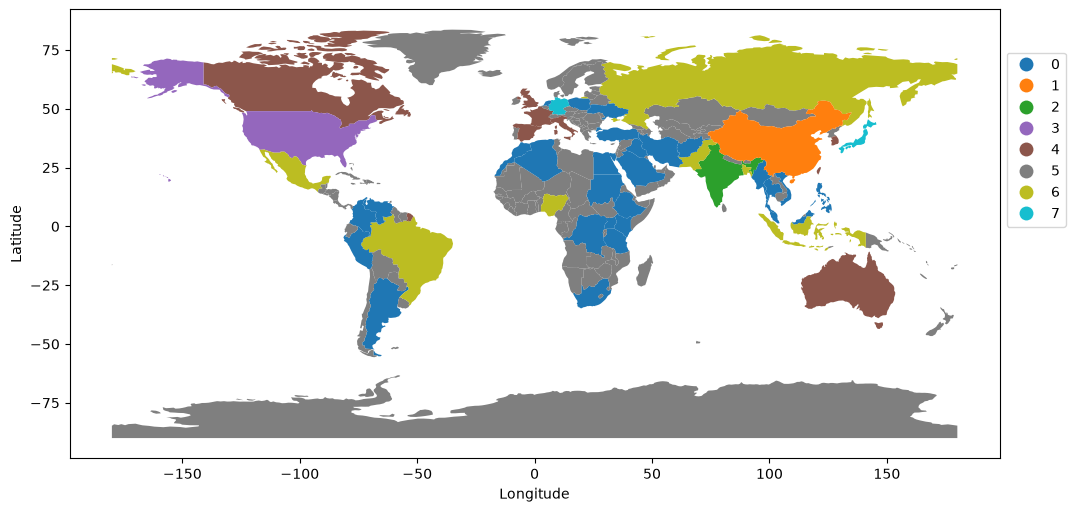

In [40]:
ax = world.plot(
    column='cluster',
    categorical=True,
    legend=True,
    legend_kwds={
        'loc': 'lower left',
        'bbox_to_anchor': (1, 0.5)
    },
    figsize=(12, 8)
)

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

plt.show()

### Exercise 4: Advanced multidimensional geospatial plot

#### Create a multidimensional plot with countries sized by their population, coloured by their GDP per capita, and apply a different marker for each continent.

#### **Hint:** Use 'plot' method with various parameters and consider using 'continent' for markers

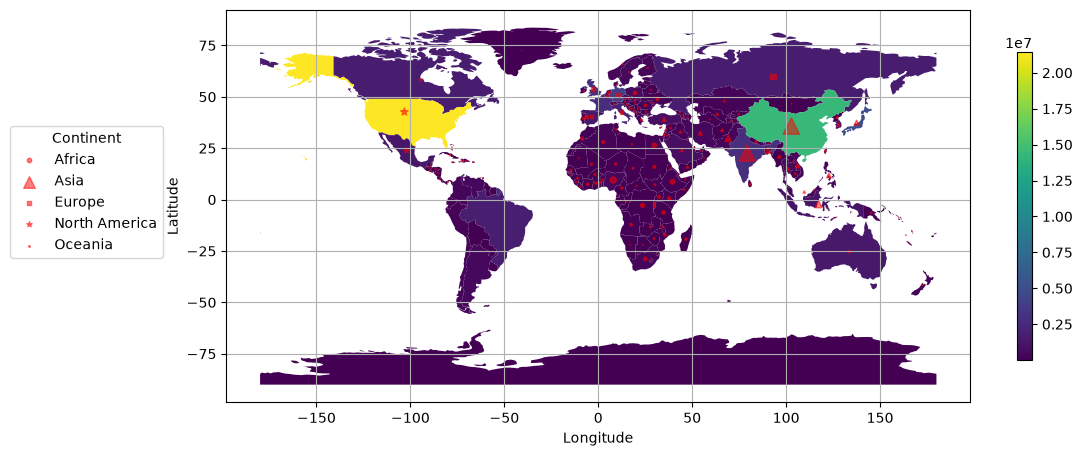

In [56]:
# load example geospatial dataset
world = gpd.read_file('/vsicurl/https://github.com/Explore-AI/Public-Data/raw/master/naturalearth_lowres/ne_110m_admin_0_countries.shp')

# world['GDP_per_capita'] = (
#     world['GDP_MD'] * 1000000
# ) / world['POP_EST']

# Plot countries using GDP per capita
ax = world.plot(
    # column='GDP_per_capita',
    column='GDP_MD',
    cmap='viridis',
    legend=True,
    figsize=(12, 8),
    legend_kwds={'shrink': 0.5}
)

# reproject before calculating centroids
world_points = world.to_crs("ESRI:54009").copy()

world_points['geometry'] = world_points.geometry.centroid

world_points = world_points.to_crs(world.crs)

# Assign a marker to each continent
continent_markers = {
    'Africa': 'o',
    'Asia': '^',
    'Europe': 's',
    'North America': '*',
    'Oceania': 'X'
}

# Plot each continent separately
for continent, marker in continent_markers.items():
    subset = world_points[
        world_points['CONTINENT'] == continent
    ]
    subset.plot(
        ax=ax,
        marker=marker,
        markersize=subset['POP_EST'] / 10000000,
        color='red',
        alpha=0.5,
        label=continent
    )

ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')

# COntinent Legend
ax.legend(
    title='Continent',
    loc='lower left',
    bbox_to_anchor=(-0.30, 0.35)
)

plt.grid(True)
plt.show()